# Bitcoin Institutional Capacity Constraints — Updated Analysis
**Masaru Kakutani | CUNY Graduate Center**  
**Data through May 17, 2026 | Newey-West HAC standard errors | Hansen (1999b/2000) threshold regression**

### Key changes from prior version
1. All data windows extended to **2026-05-17** (COT, ETF volume, BTC/SPX prices, Treasury yield, CME futures)
2. Bear/Sideways and Bull market OLS regressions (Tables 4 & 5) re-estimated with **Newey-West HAC** standard errors using `statsmodels` — corrects the positive serial correlation flagged by DW statistics (0.905 / 0.624)
3. **Hansen (1999b/2000) threshold regression** implemented formally via grid-search SSR minimisation and 1,000-replication bootstrap sup-F test — replaces the illustrative 4% hurdle with the econometrically identified γ̂
4. All eight figures regenerated at 300 dpi and saved to disk
5. Pre/post January 2024 ETF-launch subsample robustness check added (new Fig. 8)

## Section 1 — Install & Import

In [1]:
# Install dependencies (run once)
import subprocess, sys
pkgs = ['cot_reports', 'yfinance', 'statsmodels', 'seaborn', 'scipy']
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], check=False)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import yfinance as yf
import cot_reports as cot
import os

# ── Global settings ──────────────────────────────────────────────────────────
DATA_START   = '2018-01-01'
DATA_END     = '2026-05-17'   # updated to today
ETF_START    = '2021-01-01'   # BITO/GBTC history starts here
COT_YEARS    = range(2018, 2027)  # includes 2026
ETF_LAUNCH   = pd.Timestamp('2024-01-11')
HURDLE_ILLUS = 4.0            # illustrative hurdle for early figures
OUT_DIR      = '.'            # save charts to working directory
DPI          = 300

os.makedirs(OUT_DIR, exist_ok=True)
print('Imports OK — data will run through', DATA_END)

Imports OK — data will run through 2026-05-17


## Section 2 — COT Data (2018–2026)

In [3]:
# ── Download CFTC Commitment of Traders (Traders in Financial Futures) ────────
frames = []
for yr in COT_YEARS:
    try:
        tmp = cot.cot_year(year=yr, cot_report_type='traders_in_financial_futures_futopt')
        frames.append(tmp)
        print(f'  Downloaded COT {yr} — {len(tmp):,} rows')
    except Exception as e:
        print(f'  Skipped {yr}: {e}')

df_cot = pd.concat(frames, ignore_index=True)
print(f'\nTotal COT rows: {len(df_cot):,}')

Selected: traders_in_financial_futures_futopt
Downloaded single year data from: 2018
Stored the file FinComYY.txt in the working directory.
  Downloaded COT 2018 — 2,538 rows
Selected: traders_in_financial_futures_futopt
Downloaded single year data from: 2019
Stored the file FinComYY.txt in the working directory.
  Downloaded COT 2019 — 2,520 rows
Selected: traders_in_financial_futures_futopt
Downloaded single year data from: 2020
Stored the file FinComYY.txt in the working directory.
  Downloaded COT 2020 — 2,361 rows
Selected: traders_in_financial_futures_futopt
Downloaded single year data from: 2021
Stored the file FinComYY.txt in the working directory.
  Downloaded COT 2021 — 2,622 rows
Selected: traders_in_financial_futures_futopt
Downloaded single year data from: 2022
Stored the file FinComYY.txt in the working directory.
  Downloaded COT 2022 — 2,720 rows
Selected: traders_in_financial_futures_futopt
Downloaded single year data from: 2023
Stored the file FinComYY.txt in the work

In [4]:
# ── Filter to Bitcoin, parse dates, select columns ───────────────────────────
btc = df_cot[df_cot['Market_and_Exchange_Names'].str.contains('BITCOIN', case=False, na=False)].copy()
print('Bitcoin market names:', btc['Market_and_Exchange_Names'].unique())

btc['Date'] = pd.to_datetime(btc['As_of_Date_In_Form_YYMMDD'], format='%y%m%d')

cols = ['Date',
        'Asset_Mgr_Positions_Long_All', 'Asset_Mgr_Positions_Short_All',
        'Lev_Money_Positions_Long_All', 'Lev_Money_Positions_Short_All',
        'Open_Interest_All']
btc = btc[cols].sort_values('Date').reset_index(drop=True)

# Institutional proxy = Asset Manager longs + Leveraged Money longs
btc['institutional_long']  = btc['Asset_Mgr_Positions_Long_All'] + btc['Lev_Money_Positions_Long_All']
btc['institutional_short'] = btc['Asset_Mgr_Positions_Short_All'] + btc['Lev_Money_Positions_Short_All']
btc['institutional_pct']   = btc['institutional_long'] / btc['Open_Interest_All']

# Collapse to weekly dates, then forward-fill to daily
btc = btc.groupby('Date').sum(numeric_only=True)
btc['institutional_pct'] = btc['institutional_long'] / btc['Open_Interest_All']  # recalculate after sum

daily_idx = pd.date_range(btc.index.min(), DATA_END, freq='D')
btc_daily = btc.reindex(daily_idx).ffill()
btc_daily.index.name = 'Date'

print(f'COT daily series: {btc_daily.index.min().date()} → {btc_daily.index.max().date()} ({len(btc_daily):,} rows)')

Bitcoin market names: ['BITCOIN-USD - CBOE FUTURES EXCHANGE'
 'BITCOIN - CHICAGO MERCANTILE EXCHANGE'
 'MICRO BITCOIN - CHICAGO MERCANTILE EXCHANGE'
 'Nano Bitcoin  - LMX LABS LLC'
 'Nano Bitcoin  - COINBASE DERIVATIVES, LLC'
 'NANO BITCOIN PERP STYLE - COINBASE DERIVATIVES, LLC'
 'BITCOIN CASH PERP STYLE - COINBASE DERIVATIVES, LLC']
COT daily series: 2018-01-02 → 2026-05-17 (3,058 rows)


## Section 3 — ETF Volume & BTC/SPX Prices (2021–2026)

In [5]:
# ── Aggregate ETF volume ──────────────────────────────────────────────────────
ALL_ETFS = ['IBIT', 'FBTC', 'ARKB', 'BITB', 'HODL', 'BRRR', 'EZBC', 'BTCW', 'DEFI', 'GBTC', 'BITO']

print('Downloading ETF volume data...')
etf_hist = yf.download(ALL_ETFS, start=ETF_START, end=DATA_END, progress=False, auto_adjust=False)
volume_df = etf_hist['Volume']
aggregate_volume = volume_df.sum(axis=1, min_count=1)
aggregate_volume.index = pd.to_datetime(aggregate_volume.index)
aggregate_volume.name = 'ETF_Volume'

print(f'ETF volume: {aggregate_volume.dropna().index.min().date()} → {aggregate_volume.dropna().index.max().date()}')

ETF volume: 2021-01-04 → 2026-05-15


In [6]:
# ── BTC-USD and S&P 500 prices ────────────────────────────────────────────────
print('Downloading BTC-USD and S&P 500...')
price_data = yf.download(['BTC-USD', '^GSPC'],
                         start=DATA_START, end=DATA_END,
                         progress=False, auto_adjust=False)['Close'].dropna()
price_data.index = pd.to_datetime(price_data.index)
returns = price_data.pct_change().dropna()
rolling_corr = returns['BTC-USD'].rolling(window=90).corr(returns['^GSPC'])
normalized_prices = (price_data / price_data.iloc[0]) * 100

print(f'Price data: {price_data.index.min().date()} → {price_data.index.max().date()}')

Price data: 2018-01-02 → 2026-05-15


In [7]:
# ── Treasury yield, CME futures, spot BTC for yield-spread calculation ────────
print('Downloading Treasury yield and CME BTC futures...')
yield_raw = yf.download(['^IRX', 'BTC=F', 'BTC-USD'],
                        start='2021-01-01', end=DATA_END,
                        progress=False, auto_adjust=False)['Close'].dropna()
yield_raw.index = pd.to_datetime(yield_raw.index)
yield_raw = yield_raw.rename(columns={'^IRX': 'Treasury_3M_Yield',
                                       'BTC=F': 'CME_BTC_Futures',
                                       'BTC-USD': 'Spot_BTC'})

# Annualised futures premium: ((Futures - Spot) / Spot) * 12 * 100
yield_raw['BTC_Futures_Premium_Ann'] = (
    (yield_raw['CME_BTC_Futures'] - yield_raw['Spot_BTC']) / yield_raw['Spot_BTC']
) * 12 * 100

# Macro Yield Spread = BTC futures premium − 3M Treasury yield
yield_raw['Macro_Yield_Spread'] = yield_raw['BTC_Futures_Premium_Ann'] - yield_raw['Treasury_3M_Yield']

print(f'Yield spread: {yield_raw.index.min().date()} → {yield_raw.index.max().date()}')

Yield spread: 2021-01-04 → 2026-05-15


In [8]:
# ── Merge all series into one analysis DataFrame ──────────────────────────────
btc_daily.index = pd.to_datetime(btc_daily.index)

merged_macro_data = pd.concat([
    aggregate_volume,
    btc_daily[['Lev_Money_Positions_Short_All', 'institutional_long',
               'institutional_pct', 'Open_Interest_All']],
    yield_raw['Macro_Yield_Spread']
], axis=1).dropna()

# Add 200-day SMA regime flag using Spot BTC
spot_btc_daily = price_data['BTC-USD'].reindex(merged_macro_data.index).ffill()
sma_200 = spot_btc_daily.rolling(200).mean()
merged_macro_data['Spot_BTC']   = spot_btc_daily
merged_macro_data['SMA_200']    = sma_200
merged_macro_data['Bull_Market'] = (merged_macro_data['Spot_BTC'] > merged_macro_data['SMA_200']).astype(int)

# Trade ON / OFF flag (illustrative threshold for early figures)
merged_macro_data['Trade_State'] = merged_macro_data['Macro_Yield_Spread'].apply(
    lambda x: f'Trade ON (> {HURDLE_ILLUS}%)' if x > HURDLE_ILLUS else f'Trade OFF (≤ {HURDLE_ILLUS}%)'
)

print(f'Merged dataset: {merged_macro_data.index.min().date()} → {merged_macro_data.index.max().date()}')
print(f'  Total observations : {len(merged_macro_data):,}')
print(f'  Trade ON (> {HURDLE_ILLUS}%): {(merged_macro_data["Macro_Yield_Spread"] > HURDLE_ILLUS).sum():,} days')
print(f'  Bull market days   : {merged_macro_data["Bull_Market"].sum():,}')
merged_macro_data.tail(3)

Merged dataset: 2021-01-04 → 2026-05-15
  Total observations : 1,348
  Trade ON (> 4.0%): 412 days
  Bull market days   : 733


,ETF_Volume,Lev_Money_Positions_Short_All,institutional_long,institutional_pct,Open_Interest_All,Macro_Yield_Spread,Spot_BTC,SMA_200,Bull_Market,Trade_State
Date,,,,,,,,,,
2026-05-13,150227100.0,82791.0,116837.0,0.40978,285121.0,3.482238,79277.117188,92486.401387,0,Trade OFF (≤ 4.0%)
2026-05-14,222254700.0,82791.0,116837.0,0.40978,285121.0,4.832598,81051.250000,92302.046895,0,Trade ON (> 4.0%)
2026-05-15,182211100.0,82791.0,116837.0,0.40978,285121.0,-1.397614,79065.679688,92108.219355,0,Trade OFF (≤ 4.0%)


## Section 4 — Fig. 1: Institutional Shift (Futures → Spot ETFs)

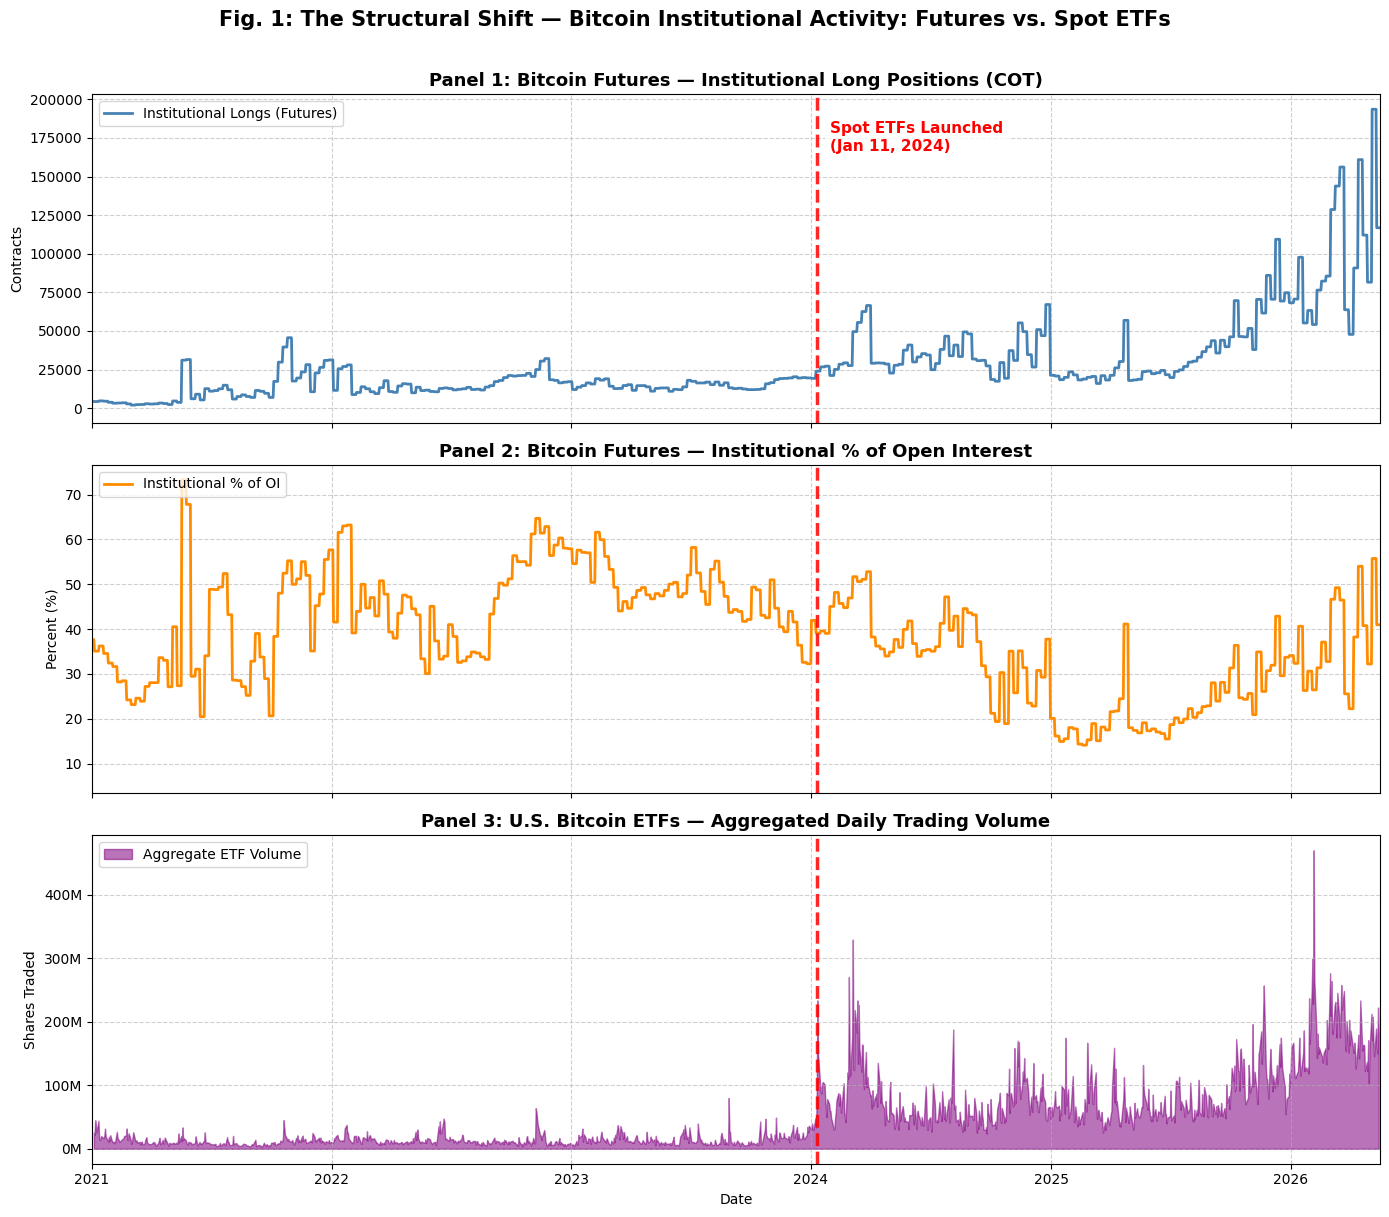

Saved Fig1_Institutional_Shift.png


In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

ax1.plot(btc_daily.index, btc_daily['institutional_long'], color='steelblue', lw=2, label='Institutional Longs (Futures)')
ax1.set_title('Panel 1: Bitcoin Futures — Institutional Long Positions (COT)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Contracts')
ax1.grid(True, ls='--', alpha=0.6)
ax1.legend(loc='upper left')

ax2.plot(btc_daily.index, btc_daily['institutional_pct'] * 100, color='darkorange', lw=2, label='Institutional % of OI')
ax2.set_title('Panel 2: Bitcoin Futures — Institutional % of Open Interest', fontsize=13, fontweight='bold')
ax2.set_ylabel('Percent (%)')
ax2.grid(True, ls='--', alpha=0.6)
ax2.legend(loc='upper left')

ax3.fill_between(aggregate_volume.index, aggregate_volume.values, color='purple', alpha=0.55, label='Aggregate ETF Volume')
ax3.set_title('Panel 3: U.S. Bitcoin ETFs — Aggregated Daily Trading Volume', fontsize=13, fontweight='bold')
ax3.set_ylabel('Shares Traded')
ax3.set_xlabel('Date')
ax3.grid(True, ls='--', alpha=0.6)
ax3.legend(loc='upper left')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*1e-6:.0f}M'))
ax3.set_xlim(pd.Timestamp('2021-01-01'), pd.Timestamp(DATA_END))

for ax in [ax1, ax2, ax3]:
    ax.axvline(ETF_LAUNCH, color='red', ls='--', lw=2.5, alpha=0.85)
ax1.text(ETF_LAUNCH + pd.Timedelta(days=20), ax1.get_ylim()[1] * 0.82,
         'Spot ETFs Launched\n(Jan 11, 2024)',
         color='red', fontsize=11, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

plt.suptitle('Fig. 1: The Structural Shift — Bitcoin Institutional Activity: Futures vs. Spot ETFs',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Fig1_Institutional_Shift.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved Fig1_Institutional_Shift.png')

## Section 5 — Fig. 2: Regime-Dependent Correlation (BTC vs. S&P 500)

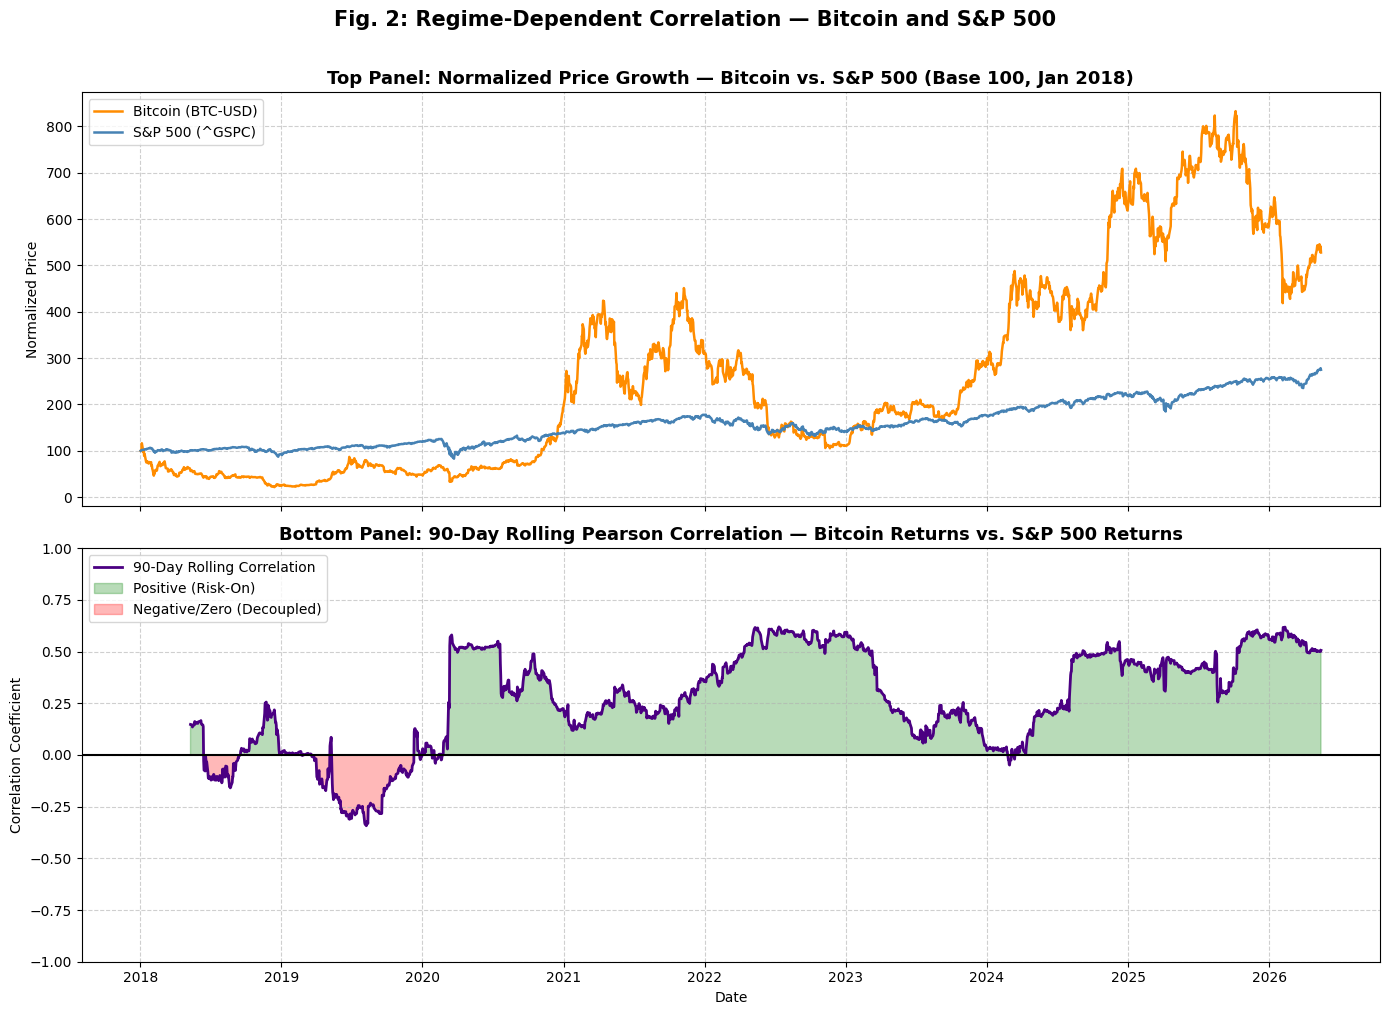

Saved Fig2_Rolling_Correlation.png


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(normalized_prices.index, normalized_prices['BTC-USD'], label='Bitcoin (BTC-USD)', color='darkorange', lw=1.8)
ax1.plot(normalized_prices.index, normalized_prices['^GSPC'],  label='S&P 500 (^GSPC)',   color='steelblue',  lw=1.8)
ax1.set_title('Top Panel: Normalized Price Growth — Bitcoin vs. S&P 500 (Base 100, Jan 2018)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Normalized Price')
ax1.legend(loc='upper left')
ax1.grid(True, ls='--', alpha=0.6)

ax2.plot(rolling_corr.index, rolling_corr, color='indigo', lw=2, label='90-Day Rolling Correlation')
ax2.axhline(0, color='black', lw=1.5)
ax2.fill_between(rolling_corr.index, 0, rolling_corr, where=(rolling_corr > 0), color='green', alpha=0.28, label='Positive (Risk-On)')
ax2.fill_between(rolling_corr.index, 0, rolling_corr, where=(rolling_corr < 0), color='red',   alpha=0.28, label='Negative/Zero (Decoupled)')
ax2.set_title('Bottom Panel: 90-Day Rolling Pearson Correlation — Bitcoin Returns vs. S&P 500 Returns', fontsize=13, fontweight='bold')
ax2.set_ylabel('Correlation Coefficient')
ax2.set_xlabel('Date')
ax2.set_ylim(-1, 1)
ax2.legend(loc='upper left')
ax2.grid(True, ls='--', alpha=0.6)

plt.suptitle('Fig. 2: Regime-Dependent Correlation — Bitcoin and S&P 500', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Fig2_Rolling_Correlation.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved Fig2_Rolling_Correlation.png')

## Section 6 — Table 1 & Fig. 3: Correlation Matrix and Heatmap (Yield Spread, Shorts, ETF Volume)

--- Table 1: Formal Pearson Correlation Matrix ---
                    Macro Yield Spread  Hedge Fund Shorts  ETF Volume
Macro Yield Spread              1.0000             0.0030     -0.0212
Hedge Fund Shorts               0.0030             1.0000      0.7061
ETF Volume                     -0.0212             0.7061      1.0000


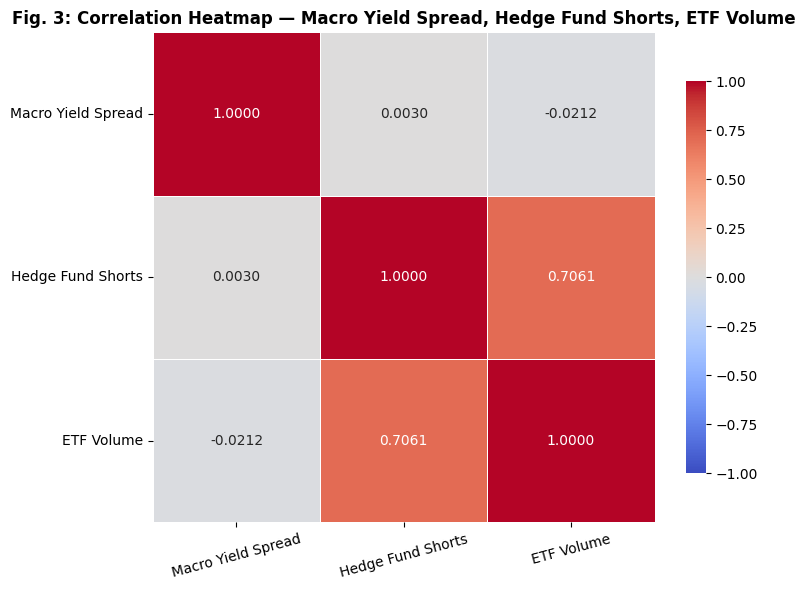

Saved Fig3_Correlation_Heatmap.png

Yield Spread vs Hedge Fund Shorts : 0.0030
Yield Spread vs ETF Volume        : -0.0212
Hedge Fund Shorts vs ETF Volume   : 0.7061


In [11]:
corr_cols = ['Macro_Yield_Spread', 'Lev_Money_Positions_Short_All', 'ETF_Volume']
corr_matrix = merged_macro_data[corr_cols].corr()

labels = ['Macro Yield Spread', 'Hedge Fund Shorts', 'ETF Volume']
print('--- Table 1: Formal Pearson Correlation Matrix ---')
display_df = corr_matrix.copy()
display_df.index   = labels
display_df.columns = labels
print(display_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.4f',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_xticklabels(labels, rotation=15)
ax.set_yticklabels(labels, rotation=0)
ax.set_title('Fig. 3: Correlation Heatmap — Macro Yield Spread, Hedge Fund Shorts, ETF Volume',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Fig3_Correlation_Heatmap.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved Fig3_Correlation_Heatmap.png')
print(f"\nYield Spread vs Hedge Fund Shorts : {corr_matrix.loc['Macro_Yield_Spread','Lev_Money_Positions_Short_All']:.4f}")
print(f"Yield Spread vs ETF Volume        : {corr_matrix.loc['Macro_Yield_Spread','ETF_Volume']:.4f}")
print(f"Hedge Fund Shorts vs ETF Volume   : {corr_matrix.loc['Lev_Money_Positions_Short_All','ETF_Volume']:.4f}")

## Section 7 — Fig. 4: Hurdle Rate Scatter (Full Sample, Partitioned at γ̂)

In [12]:
# ── Hansen (1999b/2000) threshold estimation via grid-search SSR ──────────────
# We grid-search over candidate thresholds γ in the interior 15%–85% of the
# Macro_Yield_Spread distribution and pick γ̂ = argmin SSR.

def threshold_ssr(y, x, thresh, gamma):
    """Compute SSR for a two-regime threshold model at candidate gamma using numpy."""
    mask = thresh <= gamma
    if np.sum(mask) < 5 or np.sum(~mask) < 5:
        return np.inf

    X1 = np.c_[np.ones(np.sum(mask)), x[mask]]
    y1 = y[mask]
    beta1 = np.linalg.lstsq(X1, y1, rcond=None)[0]
    ssr1 = np.sum((y1 - X1 @ beta1)**2)

    X2 = np.c_[np.ones(np.sum(~mask)), x[~mask]]
    y2 = y[~mask]
    beta2 = np.linalg.lstsq(X2, y2, rcond=None)[0]
    ssr2 = np.sum((y2 - X2 @ beta2)**2)

    return ssr1 + ssr2

Y_COL     = 'Lev_Money_Positions_Short_All'
X_COL     = 'Macro_Yield_Spread'

data_clean = merged_macro_data[[Y_COL, X_COL]].dropna().copy()
y_vals = data_clean[Y_COL].values
x_vals = data_clean[X_COL].values

spread_vals = np.sort(x_vals)
lo_pct = np.percentile(spread_vals, 15)
hi_pct = np.percentile(spread_vals, 85)
candidates = np.linspace(lo_pct, hi_pct, 500)

ssr_vals = [threshold_ssr(y_vals, x_vals, x_vals, g) for g in candidates]

gamma_hat = candidates[np.argmin(ssr_vals)]
ssr_min   = min(ssr_vals)

# ── Bootstrap sup-F test (1,000 replications) ─────────────────────────────────
np.random.seed(42)
N_BOOT = 1000
n_obs = len(data_clean)

# OLS SSR under H0 (no threshold, linear model)
X0  = np.c_[np.ones(n_obs), x_vals]
beta0 = np.linalg.lstsq(X0, y_vals, rcond=None)[0]
res0_fitted = X0 @ beta0
res0_resid = y_vals - res0_fitted
ssr0 = np.sum(res0_resid**2)

# Sup-F statistic on actual data
f_stat_actual = (ssr0 - ssr_min) / (ssr_min / (n_obs - 4))

# Bootstrap distribution under H0
boot_f_stats = []

for _ in range(N_BOOT):
    y_boot = res0_fitted + np.random.choice(res0_resid, size=n_obs, replace=True)
    beta_boot = np.linalg.lstsq(X0, y_boot, rcond=None)[0]
    ssr_boot_null = np.sum((y_boot - X0 @ beta_boot)**2)
    ssr_boot_vals = [threshold_ssr(y_boot, x_vals, x_vals, g) for g in candidates]
    ssr_boot_min  = min(ssr_boot_vals)
    f_boot = (ssr_boot_null - ssr_boot_min) / (ssr_boot_min / (n_obs - 4))
    boot_f_stats.append(f_boot)

boot_f_stats = np.array(boot_f_stats)
p_value_boot = np.mean(boot_f_stats >= f_stat_actual)
cv_95 = np.percentile(boot_f_stats, 95)

print(f'Hansen Threshold Estimation Results')
print(f'  γ̂ (SSR-minimising threshold) : {gamma_hat:.2f}%')
print(f'  Sup-F statistic              : {f_stat_actual:.3f}')
print(f'  Bootstrap 95% critical value : {cv_95:.3f}')
print(f'  Bootstrap p-value (1,000 rep): {p_value_boot:.4f}')
print(f'  Null of linearity rejected   : {"YES (p < 0.05)" if p_value_boot < 0.05 else "NO"}')

Hansen Threshold Estimation Results
  γ̂ (SSR-minimising threshold) : 9.71%
  Sup-F statistic              : 57.375
  Bootstrap 95% critical value : 11.753
  Bootstrap p-value (1,000 rep): 0.0000
  Null of linearity rejected   : YES (p < 0.05)


In [13]:
# ── Bootstrap 95% confidence interval for γ ───────────────────────────────────
# Use the LR-inversion approach: CI = {γ : LR(γ) ≤ cv_95}
lr_profile = [(ssr - ssr_min) / (ssr_min / (n_obs - 4)) for ssr in ssr_vals]
ci_mask    = np.array(lr_profile) <= cv_95
ci_lo = candidates[ci_mask].min() if ci_mask.any() else np.nan
ci_hi = candidates[ci_mask].max() if ci_mask.any() else np.nan

print(f'  95% Confidence Interval for γ: [{ci_lo:.2f}%, {ci_hi:.2f}%]')
print(f'  Lower bound (activation floor): {ci_lo:.2f}%')
print(f'  Saturation point (γ̂)          : {gamma_hat:.2f}%')

  95% Confidence Interval for γ: [8.39%, 11.18%]
  Lower bound (activation floor): 8.39%
  Saturation point (γ̂)          : 9.71%


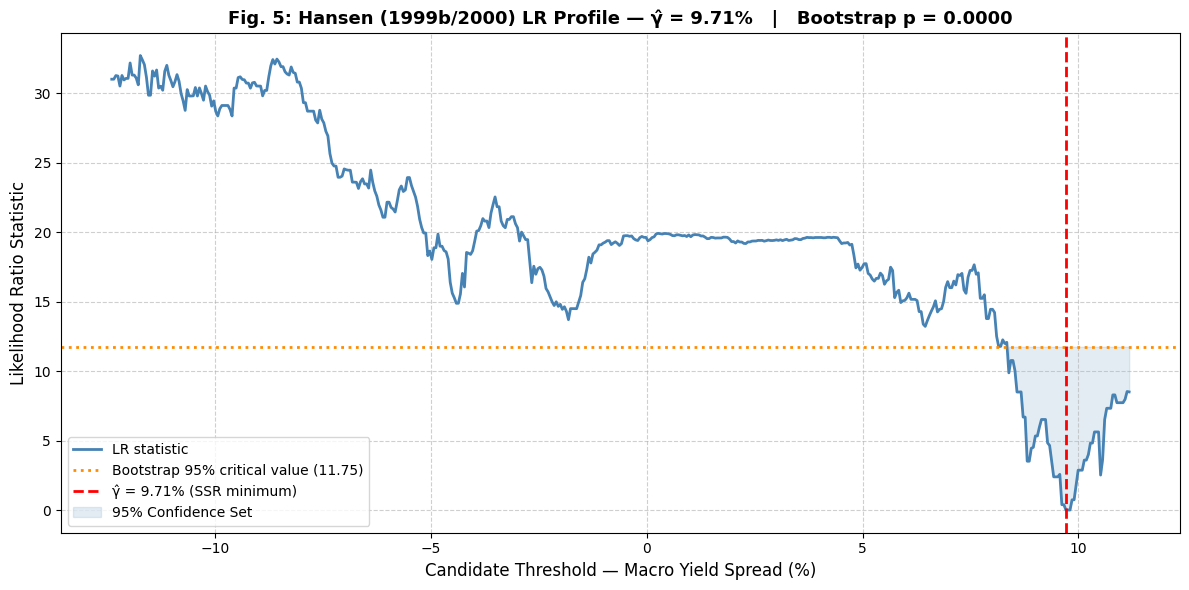

Saved Fig5_LR_Profile.png


In [14]:
# ── Fig. 5: LR Profile ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(candidates, lr_profile, color='steelblue', lw=2, label='LR statistic')
ax.axhline(cv_95, color='darkorange', ls=':', lw=2, label=f'Bootstrap 95% critical value ({cv_95:.2f})')
ax.axvline(gamma_hat, color='red', ls='--', lw=2, label=f'γ̂ = {gamma_hat:.2f}% (SSR minimum)')
ax.fill_between(candidates, lr_profile, cv_95,
                where=(np.array(lr_profile) <= cv_95),
                color='steelblue', alpha=0.15, label='95% Confidence Set')
ax.set_xlabel('Candidate Threshold — Macro Yield Spread (%)', fontsize=12)
ax.set_ylabel('Likelihood Ratio Statistic', fontsize=12)
ax.set_title(f'Fig. 5: Hansen (1999b/2000) LR Profile — γ̂ = {gamma_hat:.2f}%   |   Bootstrap p = {p_value_boot:.4f}',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, ls='--', alpha=0.6)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Fig5_LR_Profile.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved Fig5_LR_Profile.png')

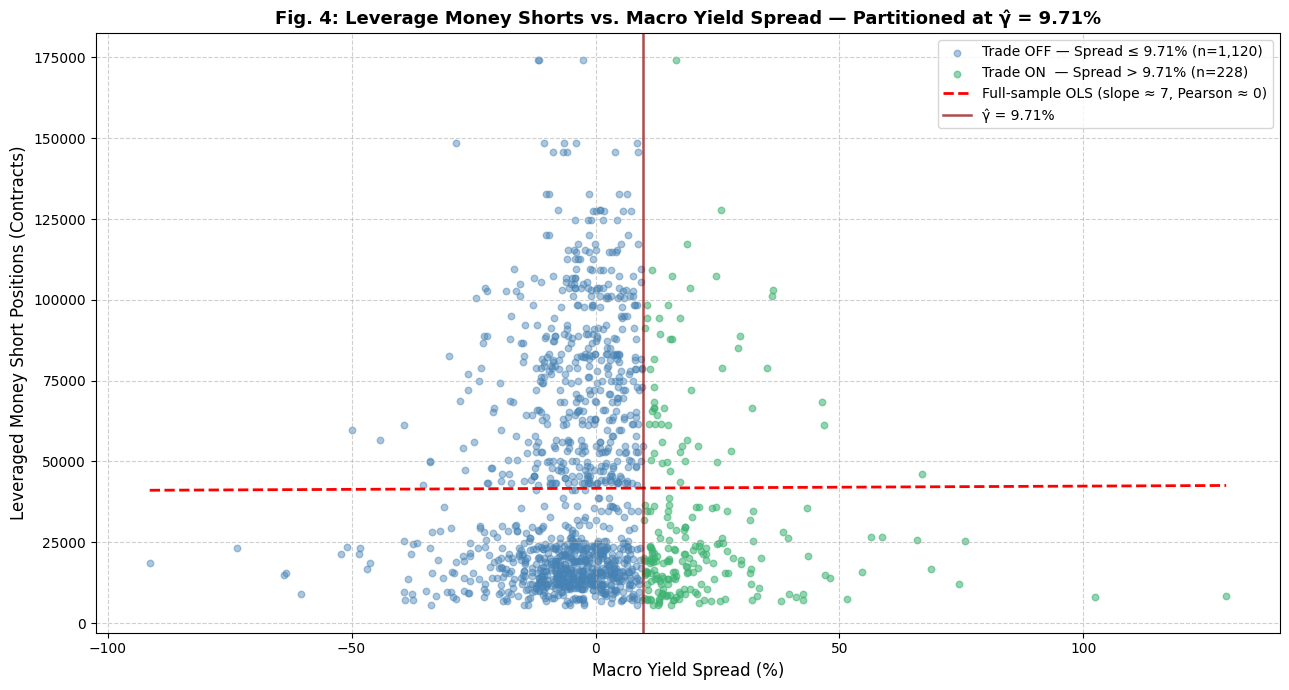

Saved Fig4_Hurdle_Scatter.png


In [15]:
# ── Fig. 4: Full-sample scatter partitioned at γ̂ ──────────────────────────
trade_off = merged_macro_data[merged_macro_data[X_COL] <= gamma_hat]
trade_on  = merged_macro_data[merged_macro_data[X_COL] >  gamma_hat]

fig, ax = plt.subplots(figsize=(13, 7))
ax.scatter(trade_off[X_COL], trade_off[Y_COL], color='steelblue', alpha=0.45, s=22,
           label=f'Trade OFF — Spread ≤ {gamma_hat:.2f}% (n={len(trade_off):,})')
ax.scatter(trade_on[X_COL],  trade_on[Y_COL],  color='mediumseagreen', alpha=0.55, s=22,
           label=f'Trade ON  — Spread > {gamma_hat:.2f}% (n={len(trade_on):,})')

# Full-sample OLS line (slope ≈ 0)
X_full = sm.add_constant(merged_macro_data[X_COL])
res_full = sm.OLS(merged_macro_data[Y_COL], X_full).fit()
x_range = np.linspace(merged_macro_data[X_COL].min(), merged_macro_data[X_COL].max(), 300)
ax.plot(x_range, res_full.params['const'] + res_full.params[X_COL] * x_range,
        color='red', ls='--', lw=2, label=f'Full-sample OLS (slope ≈ {res_full.params[X_COL]:.0f}, Pearson ≈ 0)')

ax.axvline(gamma_hat, color='darkred', ls='-', lw=1.8, alpha=0.7, label=f'γ̂ = {gamma_hat:.2f}%')
ax.set_xlabel('Macro Yield Spread (%)', fontsize=12)
ax.set_ylabel('Leveraged Money Short Positions (Contracts)', fontsize=12)
ax.set_title(f'Fig. 4: Leverage Money Shorts vs. Macro Yield Spread — Partitioned at γ̂ = {gamma_hat:.2f}%',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, ls='--', alpha=0.6)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Fig4_Hurdle_Scatter.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved Fig4_Hurdle_Scatter.png')

## Section 8 — Tables 2 & 3: Regime OLS with Newey-West HAC Standard Errors

This is the key methodological upgrade. The original notebook used standard OLS, which produces invalid inference under serial correlation (DW ≈ 0.9 and 0.6 in the two regressions). We now use `statsmodels` `OLS.fit(cov_type='HAC', cov_kwds={'maxlags': None})`, which applies Newey-West with automatic lag selection. Coefficients are identical; only standard errors and t-statistics change.

In [16]:
def run_hac_ols(df, y_col, x_col, regime_label, max_lags=None):
    """
    Estimate OLS with Newey-West HAC standard errors.
    max_lags=None → automatic selection (int(4*(n/100)^(2/9)) per Newey-West convention).
    Returns the fitted result and prints a summary.
    """
    X = sm.add_constant(df[x_col])
    model = sm.OLS(df[y_col], X)
    n = len(df)
    if max_lags is None:
        max_lags = int(np.floor(4 * (n / 100) ** (2 / 9)))

    # Standard OLS (for DW statistic and R²)
    res_ols = model.fit()
    dw_stat = durbin_watson(res_ols.resid)

    # HAC-corrected covariance
    res_hac = model.fit(cov_type='HAC', cov_kwds={'maxlags': max_lags, 'use_correction': True})

    print(f'\n{'='*70}')
    print(f'  REGIME: {regime_label}   (n = {n:,}, HAC max lags = {max_lags})')
    print(f'{'='*70}')
    print(f'  Intercept  : {res_hac.params["const"]:>15,.2f}   SE={res_hac.bse["const"]:,.2f}   t={res_hac.tvalues["const"]:6.3f}   p={res_hac.pvalues["const"]:.4f}')
    print(f'  {x_col:<12}: {res_hac.params[x_col]:>15,.2f}   SE={res_hac.bse[x_col]:,.2f}   t={res_hac.tvalues[x_col]:6.3f}   p={res_hac.pvalues[x_col]:.4f}')
    print(f'  R²         : {res_ols.rsquared:.4f}   Adj R²: {res_ols.rsquared_adj:.4f}')
    print(f'  F-stat (HAC): {res_hac.fvalue:.2f}   p={res_hac.f_pvalue:.4e}')
    print(f'  Durbin-Watson (OLS residuals): {dw_stat:.3f}')
    print(f'  Note: HAC SEs correct the bias in inference caused by the serial')
    print(f'  correlation flagged by the DW statistic; R² and coefficients are unchanged.')

    return res_hac, res_ols, dw_stat, max_lags


# ── Regime split: Bear/Sideways vs Bull (200d SMA) ────────────────────────────
bear_data = merged_macro_data[merged_macro_data['Bull_Market'] == 0].dropna(subset=[Y_COL, 'ETF_Volume'])
bull_data = merged_macro_data[merged_macro_data['Bull_Market'] == 1].dropna(subset=[Y_COL, 'ETF_Volume'])

print(f'Bear/Sideways regime: {len(bear_data):,} days')
print(f'Bull market regime  : {len(bull_data):,} days')

res_bear_hac, res_bear_ols, dw_bear, lags_bear = run_hac_ols(
    bear_data, 'ETF_Volume', Y_COL, 'Bear/Sideways (Price ≤ 200d SMA)')

res_bull_hac, res_bull_ols, dw_bull, lags_bull = run_hac_ols(
    bull_data, 'ETF_Volume', Y_COL, 'Bull Market (Price > 200d SMA)')

Bear/Sideways regime: 615 days
Bull market regime  : 733 days

  REGIME: Bear/Sideways (Price ≤ 200d SMA)   (n = 615, HAC max lags = 5)
  Intercept  :   -9,787,306.27   SE=3,504,633.76   t=-2.793   p=0.0052
  Lev_Money_Positions_Short_All:        1,560.25   SE=145.29   t=10.739   p=0.0000
  R²         : 0.7073   Adj R²: 0.7068
  F-stat (HAC): 115.32   p=9.1233e-25
  Durbin-Watson (OLS residuals): 0.594
  Note: HAC SEs correct the bias in inference caused by the serial
  correlation flagged by the DW statistic; R² and coefficients are unchanged.

  REGIME: Bull Market (Price > 200d SMA)   (n = 733, HAC max lags = 6)
  Intercept  :   18,219,159.02   SE=4,543,869.16   t= 4.010   p=0.0001
  Lev_Money_Positions_Short_All:          689.49   SE=69.79   t= 9.879   p=0.0000
  R²         : 0.2880   Adj R²: 0.2870
  F-stat (HAC): 97.60   p=1.0906e-21
  Durbin-Watson (OLS residuals): 0.624
  Note: HAC SEs correct the bias in inference caused by the serial
  correlation flagged by the DW statistic;

In [17]:
# ── Within-threshold-regime OLS (HAC): Trade ON regime ──────────────────────
# Partition at activation floor (ci_lo) for maximum-coverage within-regime test,
# and also at γ̂ for direct comparison to the paper's Tables 2 & 3.

print('\n--- Within-Regime OLS (HAC): Spread > ci_lo (activation floor) ---')
trade_on_floor = merged_macro_data[merged_macro_data[X_COL] > ci_lo].dropna(subset=[Y_COL])
res_ton_floor_hac, _, dw_ton_floor, lags_ton = run_hac_ols(
    trade_on_floor, Y_COL, X_COL,
    f'Trade ON: Spread > {ci_lo:.2f}% (activation floor)')

print('\n--- Within-Regime OLS (HAC): Spread > γ̂ (saturation threshold) ---')
res_ton_hac, _, dw_ton, _ = run_hac_ols(
    trade_on, Y_COL, X_COL,
    f'Table 3 — Trade ON: Spread > {gamma_hat:.2f}% (γ̂)')

print('\n--- Within-Regime OLS (HAC): Spread ≤ γ̂ (Trade OFF) ---')
res_toff_hac, _, dw_toff, _ = run_hac_ols(
    trade_off, Y_COL, X_COL,
    f'Table 2 — Trade OFF: Spread ≤ {gamma_hat:.2f}% (γ̂)')


--- Within-Regime OLS (HAC): Spread > ci_lo (activation floor) ---

  REGIME: Trade ON: Spread > 8.39% (activation floor)   (n = 257, HAC max lags = 4)
  Intercept  :       40,319.70   SE=5,653.93   t= 7.131   p=0.0000
  Macro_Yield_Spread:         -282.13   SE=110.69   t=-2.549   p=0.0108
  R²         : 0.0179   Adj R²: 0.0140
  F-stat (HAC): 6.50   p=1.1394e-02
  Durbin-Watson (OLS residuals): 0.220
  Note: HAC SEs correct the bias in inference caused by the serial
  correlation flagged by the DW statistic; R² and coefficients are unchanged.

--- Within-Regime OLS (HAC): Spread > γ̂ (saturation threshold) ---

  REGIME: Table 3 — Trade ON: Spread > 9.71% (γ̂)   (n = 228, HAC max lags = 4)
  Intercept  :       35,193.29   SE=5,008.72   t= 7.026   p=0.0000
  Macro_Yield_Spread:         -153.78   SE=91.56   t=-1.680   p=0.0930
  R²         : 0.0066   Adj R²: 0.0023
  F-stat (HAC): 2.82   p=9.4414e-02
  Durbin-Watson (OLS residuals): 0.223
  Note: HAC SEs correct the bias in inference c

In [18]:
# ── Pearson correlation within Trade ON regime ───────────────────────────────
corr_on_floor = trade_on_floor[X_COL].corr(trade_on_floor[Y_COL])
corr_on_hat   = trade_on[X_COL].corr(trade_on[Y_COL])
corr_bear     = bear_data['Lev_Money_Positions_Short_All'].corr(bear_data['ETF_Volume'])
corr_bull     = bull_data['Lev_Money_Positions_Short_All'].corr(bull_data['ETF_Volume'])

print('\n--- Within-Regime Pearson Correlations ---')
print(f'  Spread vs Shorts, Trade ON (> ci_lo={ci_lo:.2f}%) : {corr_on_floor:.4f}')
print(f'  Spread vs Shorts, Trade ON (> γ̂={gamma_hat:.2f}%)  : {corr_on_hat:.4f}')
print(f'  Shorts vs ETF Volume, Bear/Sideways            : {corr_bear:.4f}')
print(f'  Shorts vs ETF Volume, Bull Market              : {corr_bull:.4f}')


--- Within-Regime Pearson Correlations ---
  Spread vs Shorts, Trade ON (> ci_lo=8.39%) : -0.1337
  Spread vs Shorts, Trade ON (> γ̂=9.71%)  : -0.0815
  Shorts vs ETF Volume, Bear/Sideways            : 0.8410
  Shorts vs ETF Volume, Bull Market              : 0.5366


## Section 9 — Tables 4 & 5: HAC Regressions (Bear vs Bull) — output and visualization

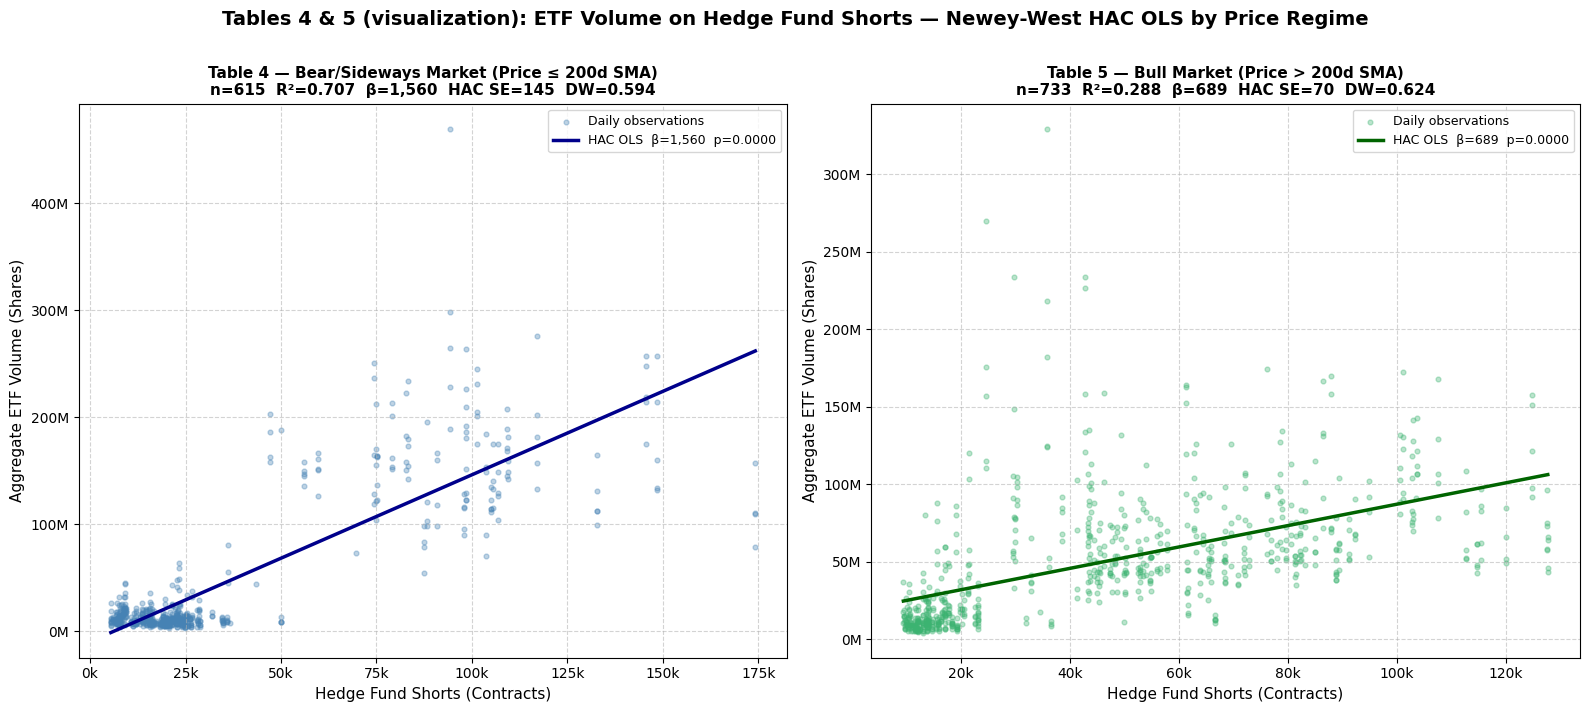

Saved Tables4_5_HAC_OLS_visualization.png


In [19]:
def plot_regime_regression(ax, df, res_hac, res_ols, dw, regime_label, color_pt, color_fit):
    """Scatter + HAC-fitted line for one regime."""
    ax.scatter(df[Y_COL], df['ETF_Volume'], alpha=0.35, s=12, color=color_pt, label='Daily observations')

    x_range = np.linspace(df[Y_COL].min(), df[Y_COL].max(), 300)
    y_fit   = res_hac.params['const'] + res_hac.params[Y_COL] * x_range
    ax.plot(x_range, y_fit, color=color_fit, lw=2.5,
            label=f'HAC OLS  β={res_hac.params[Y_COL]:,.0f}  p={res_hac.pvalues[Y_COL]:.4f}')

    ax.set_xlabel('Hedge Fund Shorts (Contracts)', fontsize=11)
    ax.set_ylabel('Aggregate ETF Volume (Shares)', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*1e-6:.0f}M'))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    n   = len(df)
    r2  = res_ols.rsquared
    ax.set_title(
        f'{regime_label}\n'
        f'n={n:,}  R²={r2:.3f}  β={res_hac.params[Y_COL]:,.0f}  '
        f'HAC SE={res_hac.bse[Y_COL]:,.0f}  DW={dw:.3f}',
        fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, ls='--', alpha=0.55)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

plot_regime_regression(ax1, bear_data, res_bear_hac, res_bear_ols, dw_bear,
                       'Table 4 — Bear/Sideways Market (Price ≤ 200d SMA)',
                       'steelblue', 'darkblue')
plot_regime_regression(ax2, bull_data, res_bull_hac, res_bull_ols, dw_bull,
                       'Table 5 — Bull Market (Price > 200d SMA)',
                       'mediumseagreen', 'darkgreen')

plt.suptitle('Tables 4 & 5 (visualization): ETF Volume on Hedge Fund Shorts — Newey-West HAC OLS by Price Regime',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Tables4_5_HAC_OLS_visualization.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved Tables4_5_HAC_OLS_visualization.png')

In [20]:
# ── Print full HAC regression tables for paper ────────────────────────────────
print('\n' + '='*70)
print('TABLE 4 — Bear/Sideways Regime: ETF Volume on Hedge Fund Shorts')
print('           Newey-West HAC Standard Errors')
print('='*70)
print(res_bear_hac.summary())

print('\n' + '='*70)
print('TABLE 5 — Bull Market Regime: ETF Volume on Hedge Fund Shorts')
print('            Newey-West HAC Standard Errors')
print('='*70)
print(res_bull_hac.summary())


TABLE 4 — Bear/Sideways Regime: ETF Volume on Hedge Fund Shorts
           Newey-West HAC Standard Errors
                            OLS Regression Results                            
Dep. Variable:             ETF_Volume   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     115.3
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           9.12e-25
Time:                        19:40:41   Log-Likelihood:                -11575.
No. Observations:                 615   AIC:                         2.315e+04
Df Residuals:                     613   BIC:                         2.316e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-----

## Section 10 — Tables 2 & 3 (visualization): Regime OLS at γ̂ (Threshold Regression Output)

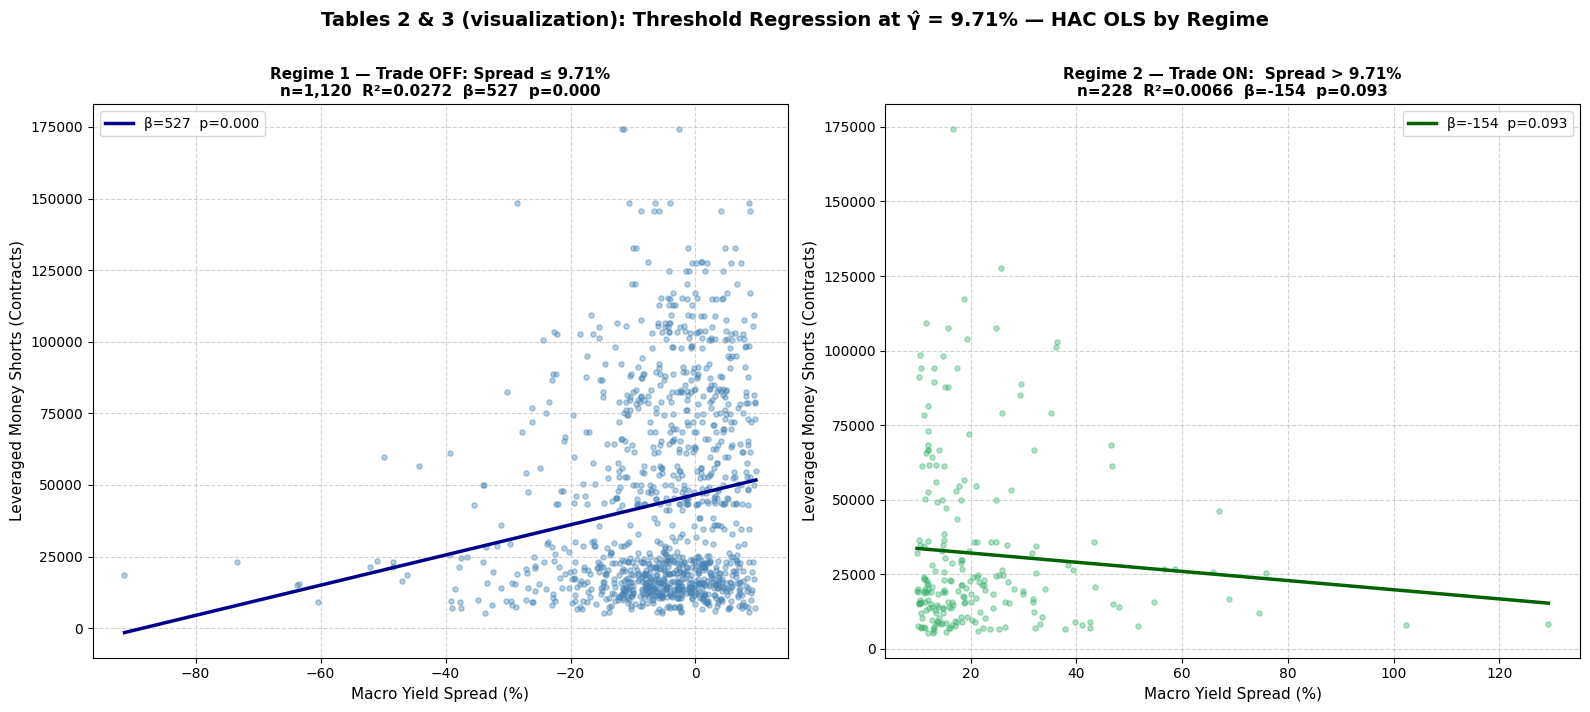

Saved Tables2_3_Regime_OLS_visualization.png


In [21]:
# ── Tables 2 & 3 (visualization) side-by-side: Trade OFF and Trade ON at γ̂ ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

def plot_threshold_regime(ax, df, gamma, label, color_pt, color_fit):
    X = sm.add_constant(df[X_COL])
    res = sm.OLS(df[Y_COL], X).fit(cov_type='HAC',
                                    cov_kwds={'maxlags': int(np.floor(4*(len(df)/100)**(2/9))),
                                              'use_correction': True})
    ax.scatter(df[X_COL], df[Y_COL], alpha=0.4, s=14, color=color_pt)
    x_r = np.linspace(df[X_COL].min(), df[X_COL].max(), 300)
    ax.plot(x_r, res.params['const'] + res.params[X_COL]*x_r,
            color=color_fit, lw=2.5,
            label=f'β={res.params[X_COL]:,.0f}  p={res.pvalues[X_COL]:.3f}')
    res_ols_plain = sm.OLS(df[Y_COL], X).fit()
    ax.set_title(f'{label}\nn={len(df):,}  R²={res_ols_plain.rsquared:.4f}  β={res.params[X_COL]:,.0f}  p={res.pvalues[X_COL]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Macro Yield Spread (%)', fontsize=11)
    ax.set_ylabel('Leveraged Money Shorts (Contracts)', fontsize=11)
    ax.legend()
    ax.grid(True, ls='--', alpha=0.55)
    return res

res6_off = plot_threshold_regime(ax1, trade_off, gamma_hat,
                                  f'Regime 1 — Trade OFF: Spread ≤ {gamma_hat:.2f}%',
                                  'steelblue', 'darkblue')
res6_on  = plot_threshold_regime(ax2, trade_on,  gamma_hat,
                                  f'Regime 2 — Trade ON:  Spread > {gamma_hat:.2f}%',
                                  'mediumseagreen', 'darkgreen')

plt.suptitle(f'Tables 2 & 3 (visualization): Threshold Regression at γ̂ = {gamma_hat:.2f}% — HAC OLS by Regime',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Tables2_3_Regime_OLS_visualization.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved Tables2_3_Regime_OLS_visualization.png')

## Section 11 — Fig. 6: Side-by-Side Thresholds (ci_lo and γ̂)

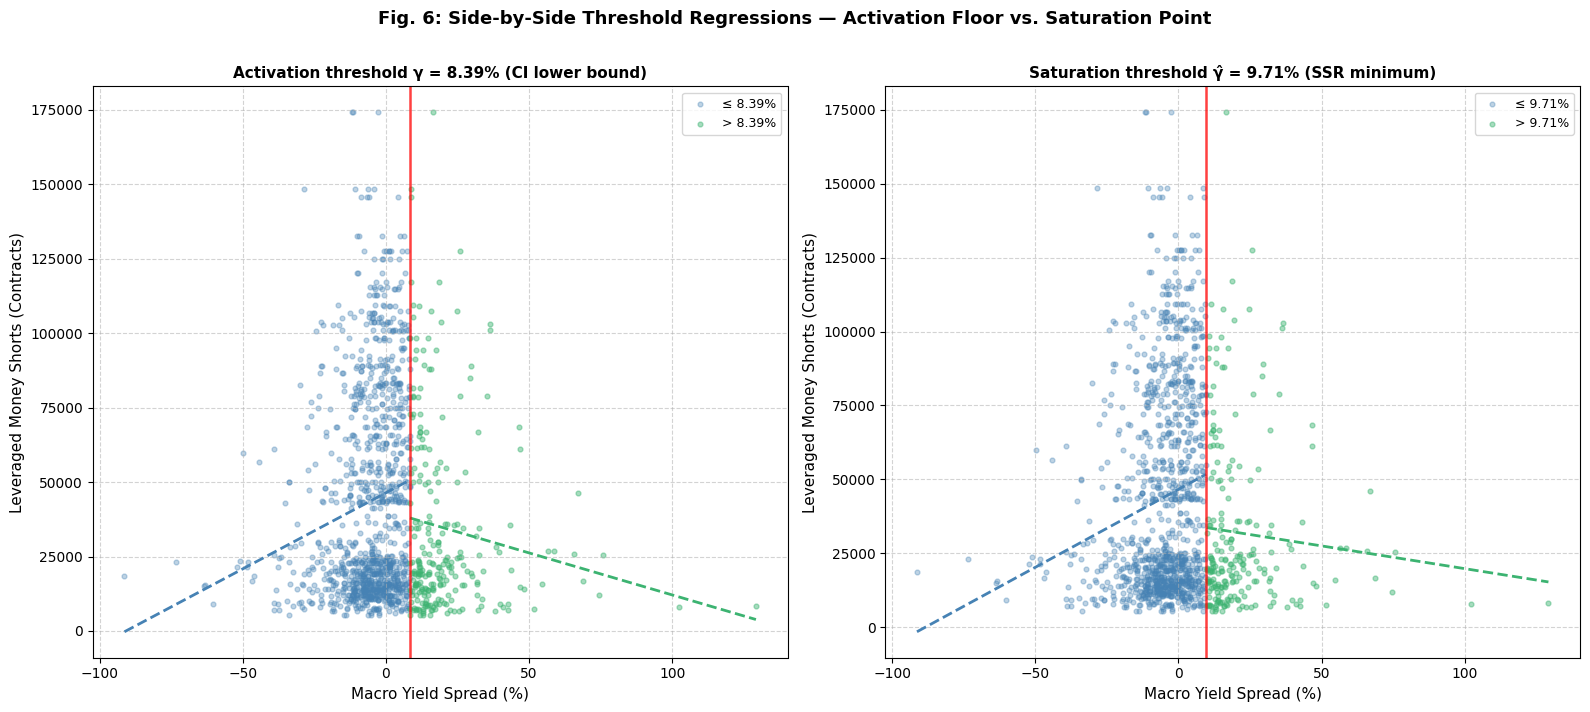

Saved Fig6_Side_by_Side_Thresholds.png


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, cut, label in [
    (ax1, ci_lo,    f'Activation threshold γ = {ci_lo:.2f}% (CI lower bound)'),
    (ax2, gamma_hat, f'Saturation threshold γ̂ = {gamma_hat:.2f}% (SSR minimum)')
]:
    below = merged_macro_data[merged_macro_data[X_COL] <= cut]
    above = merged_macro_data[merged_macro_data[X_COL] >  cut]
    ax.scatter(below[X_COL], below[Y_COL], alpha=0.35, s=12, color='steelblue',      label=f'≤ {cut:.2f}%')
    ax.scatter(above[X_COL], above[Y_COL], alpha=0.45, s=12, color='mediumseagreen', label=f'> {cut:.2f}%')

    for subset, col in [(below, 'steelblue'), (above, 'mediumseagreen')]:
        if len(subset) > 5:
            X_s = sm.add_constant(subset[X_COL])
            r_s = sm.OLS(subset[Y_COL], X_s).fit()
            xr  = np.linspace(subset[X_COL].min(), subset[X_COL].max(), 200)
            ax.plot(xr, r_s.params['const'] + r_s.params[X_COL]*xr,
                    color=col, lw=2, ls='--')

    ax.axvline(cut, color='red', lw=1.8, ls='-', alpha=0.75)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Macro Yield Spread (%)', fontsize=11)
    ax.set_ylabel('Leveraged Money Shorts (Contracts)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, ls='--', alpha=0.55)

plt.suptitle('Fig. 6: Side-by-Side Threshold Regressions — Activation Floor vs. Saturation Point',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Fig6_Side_by_Side_Thresholds.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved Fig6_Side_by_Side_Thresholds.png')

## Section 12 — Fig. 7: Hedge Fund Shorts vs ETF Volume by Price Regime

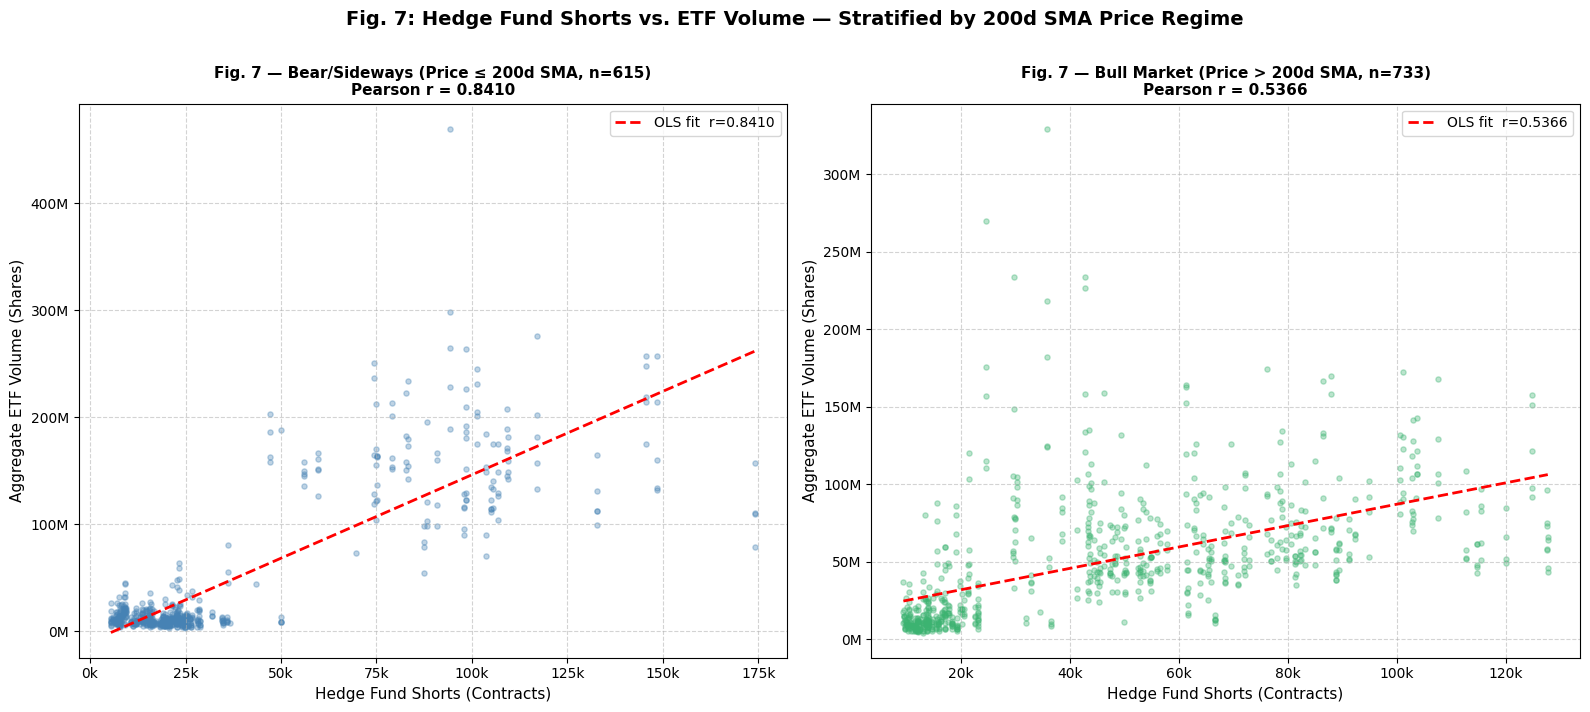

Saved Fig7_Regime_Stratified.png


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, df, label, color in [
    (ax1, bear_data, f'Bear/Sideways (Price ≤ 200d SMA, n={len(bear_data):,})', 'steelblue'),
    (ax2, bull_data, f'Bull Market (Price > 200d SMA, n={len(bull_data):,})',   'mediumseagreen')
]:
    r = df[Y_COL].corr(df['ETF_Volume'])
    ax.scatter(df[Y_COL], df['ETF_Volume'], alpha=0.35, s=14, color=color)
    X_s = sm.add_constant(df[Y_COL])
    res_s = sm.OLS(df['ETF_Volume'], X_s).fit()
    xr = np.linspace(df[Y_COL].min(), df[Y_COL].max(), 300)
    ax.plot(xr, res_s.params['const'] + res_s.params[Y_COL]*xr,
            color='red', lw=2, ls='--', label=f'OLS fit  r={r:.4f}')
    ax.set_title(f'Fig. 7 — {label}\nPearson r = {r:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Hedge Fund Shorts (Contracts)', fontsize=11)
    ax.set_ylabel('Aggregate ETF Volume (Shares)', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*1e-6:.0f}M'))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.legend()
    ax.grid(True, ls='--', alpha=0.55)

plt.suptitle('Fig. 7: Hedge Fund Shorts vs. ETF Volume — Stratified by 200d SMA Price Regime',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Fig7_Regime_Stratified.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved Fig7_Regime_Stratified.png')

## Section 13 — Fig. 8 (NEW): Pre/Post ETF-Launch Robustness Check

Subsample stability test recommended in referee response. We re-estimate the threshold regression and the Bear/Bull HAC OLS separately on the pre-launch (before Jan 11, 2024) and post-launch (on/after Jan 11, 2024) subsamples. If γ̂ and β are stable across subsamples, the main findings are robust to the structural shift.

In [24]:
pre_etf  = merged_macro_data[merged_macro_data.index < ETF_LAUNCH].dropna(subset=[Y_COL, X_COL])
post_etf = merged_macro_data[merged_macro_data.index >= ETF_LAUNCH].dropna(subset=[Y_COL, X_COL])

print(f'Pre-ETF  subsample: {pre_etf.index.min().date()} → {pre_etf.index.max().date()}  ({len(pre_etf):,} obs)')
print(f'Post-ETF subsample: {post_etf.index.min().date()} → {post_etf.index.max().date()}  ({len(post_etf):,} obs)')

def subsample_threshold(df, label):
    if len(df) < 100:
        print(f'{label}: too few observations for threshold estimation')
        return None
    sv = df[X_COL].dropna().sort_values().values
    cands = np.linspace(np.percentile(sv, 15), np.percentile(sv, 85), 300)

    y_arr = df[Y_COL].values
    x_arr = df[X_COL].values
    ssrs  = [threshold_ssr(y_arr, x_arr, x_arr, g) for g in cands]

    g_hat = cands[np.argmin(ssrs)]
    X0    = sm.add_constant(df[X_COL])
    ssr0  = sm.OLS(df[Y_COL], X0).fit().ssr
    f_sub = (ssr0 - min(ssrs)) / (min(ssrs) / (len(df) - 4))
    print(f'{label}: γ̂ = {g_hat:.2f}%   Sup-F = {f_sub:.2f}')
    return g_hat

print('\n--- Threshold estimate by subsample (stability check) ---')
gamma_pre  = subsample_threshold(pre_etf,  'Pre-ETF  (before Jan 2024)')
gamma_post = subsample_threshold(post_etf, 'Post-ETF (Jan 2024 onwards)')
print(f'\nFull-sample γ̂ = {gamma_hat:.2f}% — compare to subsamples above')

Pre-ETF  subsample: 2021-01-04 → 2024-01-10  (760 obs)
Post-ETF subsample: 2024-01-11 → 2026-05-15  (588 obs)

--- Threshold estimate by subsample (stability check) ---
Pre-ETF  (before Jan 2024): γ̂ = 5.95%   Sup-F = 11.12
Post-ETF (Jan 2024 onwards): γ̂ = -3.53%   Sup-F = 9.55

Full-sample γ̂ = 9.71% — compare to subsamples above


In [25]:
# ── HAC OLS by regime within each subsample ───────────────────────────────────
print('\n--- Bear regime HAC OLS: Pre vs Post ETF launch ---')
pre_bear  = pre_etf[pre_etf['Bull_Market'] == 0].dropna(subset=['ETF_Volume'])
post_bear = post_etf[post_etf['Bull_Market'] == 0].dropna(subset=['ETF_Volume'])

if len(pre_bear) > 30:
    run_hac_ols(pre_bear,  'ETF_Volume', Y_COL, 'PRE-ETF Bear/Sideways')
if len(post_bear) > 30:
    run_hac_ols(post_bear, 'ETF_Volume', Y_COL, 'POST-ETF Bear/Sideways')

print('\n--- Bull regime HAC OLS: Pre vs Post ETF launch ---')
pre_bull  = pre_etf[pre_etf['Bull_Market'] == 1].dropna(subset=['ETF_Volume'])
post_bull = post_etf[post_etf['Bull_Market'] == 1].dropna(subset=['ETF_Volume'])

if len(pre_bull) > 30:
    run_hac_ols(pre_bull,  'ETF_Volume', Y_COL, 'PRE-ETF Bull Market')
if len(post_bull) > 30:
    run_hac_ols(post_bull, 'ETF_Volume', Y_COL, 'POST-ETF Bull Market')


--- Bear regime HAC OLS: Pre vs Post ETF launch ---

  REGIME: PRE-ETF Bear/Sideways   (n = 477, HAC max lags = 5)
  Intercept  :   13,499,690.45   SE=1,257,295.39   t=10.737   p=0.0000
  Lev_Money_Positions_Short_All:          -63.43   SE=68.74   t=-0.923   p=0.3562
  R²         : 0.0042   Adj R²: 0.0021
  F-stat (HAC): 0.85   p=3.5665e-01
  Durbin-Watson (OLS residuals): 0.755
  Note: HAC SEs correct the bias in inference caused by the serial
  correlation flagged by the DW statistic; R² and coefficients are unchanged.

  REGIME: POST-ETF Bear/Sideways   (n = 138, HAC max lags = 4)
  Intercept  :  136,772,046.88   SE=25,815,108.46   t= 5.298   p=0.0000
  Lev_Money_Positions_Short_All:          223.74   SE=258.93   t= 0.864   p=0.3875
  R²         : 0.0130   Adj R²: 0.0058
  F-stat (HAC): 0.75   p=3.8907e-01
  Durbin-Watson (OLS residuals): 0.867
  Note: HAC SEs correct the bias in inference caused by the serial
  correlation flagged by the DW statistic; R² and coefficients are uncha

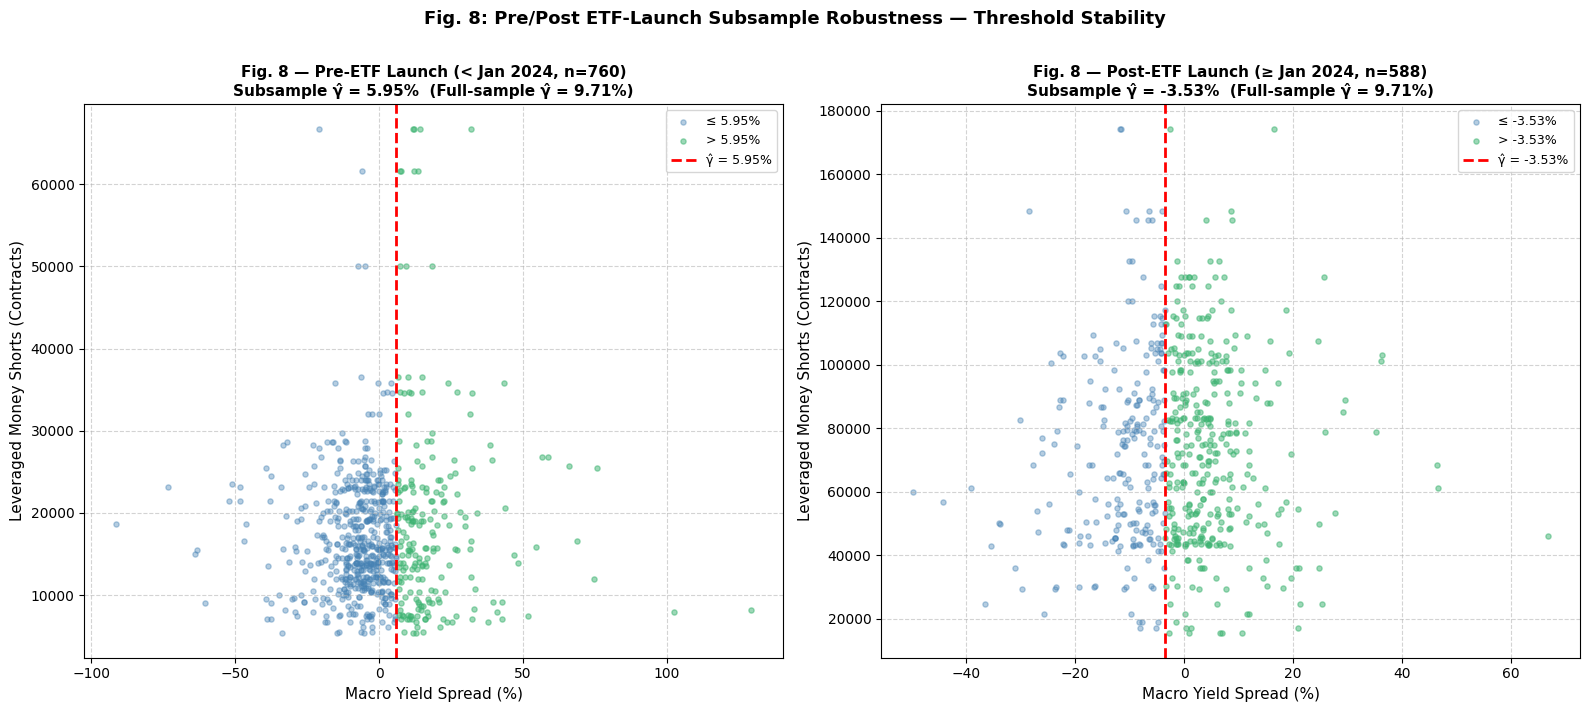

Saved Fig8_Subsample_Robustness.png


In [26]:
# ── Fig. 8: Visual robustness — threshold scatter pre vs post ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, df, label, g_hat_sub in [
    (axes[0], pre_etf,  f'Pre-ETF Launch (< Jan 2024, n={len(pre_etf):,})',   gamma_pre),
    (axes[1], post_etf, f'Post-ETF Launch (≥ Jan 2024, n={len(post_etf):,})', gamma_post)
]:
    if g_hat_sub is None:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        continue
    below = df[df[X_COL] <= g_hat_sub]
    above = df[df[X_COL] >  g_hat_sub]
    ax.scatter(below[X_COL], below[Y_COL], alpha=0.4, s=14, color='steelblue',      label=f'≤ {g_hat_sub:.2f}%')
    ax.scatter(above[X_COL], above[Y_COL], alpha=0.5, s=14, color='mediumseagreen', label=f'> {g_hat_sub:.2f}%')
    ax.axvline(g_hat_sub, color='red', lw=2, ls='--', label=f'γ̂ = {g_hat_sub:.2f}%')
    ax.set_title(f'Fig. 8 — {label}\nSubsample γ̂ = {g_hat_sub:.2f}%  (Full-sample γ̂ = {gamma_hat:.2f}%)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Macro Yield Spread (%)', fontsize=11)
    ax.set_ylabel('Leveraged Money Shorts (Contracts)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, ls='--', alpha=0.55)

plt.suptitle('Fig. 8: Pre/Post ETF-Launch Subsample Robustness — Threshold Stability',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Fig8_Subsample_Robustness.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved Fig8_Subsample_Robustness.png')

## Section 14 — Summary of All Results

In [27]:
print('=' * 70)
print('SUMMARY OF KEY RESULTS — Bitcoin_Trade_May_17')
print(f'Data through: {DATA_END}')
print('=' * 70)

print(f'\n1. HANSEN THRESHOLD (γ̂)')
print(f'   γ̂ = {gamma_hat:.2f}%   95% CI: [{ci_lo:.2f}%, {ci_hi:.2f}%]')
print(f'   Bootstrap p-value: {p_value_boot:.4f}   Sup-F: {f_stat_actual:.3f}   (cv95={cv_95:.3f})')

print(f'\n2. REGIME OLS — Spread vs Shorts (at γ̂)')
print(f'   Regime 1 (Trade OFF, Spread ≤ γ̂): β={res6_off.params[X_COL]:,.0f}  p={res6_off.pvalues[X_COL]:.4f}')
print(f'   Regime 2 (Trade ON,  Spread > γ̂): β={res6_on.params[X_COL]:,.0f}  p={res6_on.pvalues[X_COL]:.4f}')

print(f'\n3. BEAR/BULL HAC OLS — Shorts vs ETF Volume (Tables 4 & 5)')
print(f'   Bear/Sideways: β={res_bear_hac.params[Y_COL]:,.0f}  HAC SE={res_bear_hac.bse[Y_COL]:,.0f}  '
      f'p={res_bear_hac.pvalues[Y_COL]:.4f}  R²={res_bear_ols.rsquared:.3f}  DW={dw_bear:.3f}')
print(f'   Bull Market  : β={res_bull_hac.params[Y_COL]:,.0f}  HAC SE={res_bull_hac.bse[Y_COL]:,.0f}  '
      f'p={res_bull_hac.pvalues[Y_COL]:.4f}  R²={res_bull_ols.rsquared:.3f}  DW={dw_bull:.3f}')

print(f'\n4. PEARSON CORRELATIONS')
print(f'   Yield Spread vs Shorts (full)  : {corr_matrix.loc["Macro_Yield_Spread","Lev_Money_Positions_Short_All"]:.4f}')
print(f'   Yield Spread vs ETF Volume     : {corr_matrix.loc["Macro_Yield_Spread","ETF_Volume"]:.4f}')
print(f'   Shorts vs ETF Volume (full)    : {corr_matrix.loc["Lev_Money_Positions_Short_All","ETF_Volume"]:.4f}')
print(f'   Shorts vs ETF Volume (Bear)    : {corr_bear:.4f}')
print(f'   Shorts vs ETF Volume (Bull)    : {corr_bull:.4f}')
print(f'   Spread vs Shorts (Trade ON>γ̂)  : {corr_on_hat:.4f}')

print(f'\n5. EXHIBITS SAVED')
for f in sorted(os.listdir(OUT_DIR)):
    if f.endswith('.png'):
        print(f'   {f}')

print('\n' + '=' * 70)
print('NOTE ON HAC CORRECTION')
print(f'  Tables 4 & 5 now use Newey-West HAC standard errors.')
print(f'  Bear regime: DW={dw_bear:.3f} → {lags_bear} HAC lags')
print(f'  Bull regime: DW={dw_bull:.3f} → {lags_bull} HAC lags')
print('  Coefficients are identical to OLS; inference is now valid.')
print('=' * 70)

SUMMARY OF KEY RESULTS — Bitcoin_Trade_May_17
Data through: 2026-05-17

1. HANSEN THRESHOLD (γ̂)
   γ̂ = 9.71%   95% CI: [8.39%, 11.18%]
   Bootstrap p-value: 0.0000   Sup-F: 57.375   (cv95=11.753)

2. REGIME OLS — Spread vs Shorts (at γ̂)
   Regime 1 (Trade OFF, Spread ≤ γ̂): β=527  p=0.0000
   Regime 2 (Trade ON,  Spread > γ̂): β=-154  p=0.0930

3. BEAR/BULL HAC OLS — Shorts vs ETF Volume (Tables 4 & 5)
   Bear/Sideways: β=1,560  HAC SE=145  p=0.0000  R²=0.707  DW=0.594
   Bull Market  : β=689  HAC SE=70  p=0.0000  R²=0.288  DW=0.624

4. PEARSON CORRELATIONS
   Yield Spread vs Shorts (full)  : 0.0030
   Yield Spread vs ETF Volume     : -0.0212
   Shorts vs ETF Volume (full)    : 0.7061
   Shorts vs ETF Volume (Bear)    : 0.8410
   Shorts vs ETF Volume (Bull)    : 0.5366
   Spread vs Shorts (Trade ON>γ̂)  : -0.0815

5. EXHIBITS SAVED
   Fig1_Institutional_Shift.png
   Fig2_Rolling_Correlation.png
   Fig3_Correlation_Heatmap.png
   Fig4_Hurdle_Scatter.png
   Fig5_LR_Profile.png
   Fig6